In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import csv
import sys
sys.path.append('/storage/home/hcoda1/4/ashelby8/Manitoba/pyNab/src/')
import nabPy as Nab
sys.path.append('/storage/home/hcoda1/4/ashelby8/calibration/calibration/')
from FitClass import SnCalibration
from FitClass import CdCalibration
from config import conf
import FitFuncs
import pandas as pd
import pylab as py
np.set_printoptions(threshold=sys.maxsize)
pd.set_option("display.max_colwidth", 15)

In [9]:
runs = [1389,1374,1391,1392,1393]
runs2 = [1375,1376,1377,1379,1381,1383,1385]
# runs = [1375,1376,1377,1379,1381]
# 1389,1374,1391,1392,1393,1395
runs_Cd = [1407,1751]
[1749,1751,1756,1763]
# 1749,1751,1756,1763,1769,1772
bias = [-320,-300,-250,-180,-120]
bias2 = [-320,-300,-250,-210,-180,-150,-120]
bias_Cd = [-300,-240]

In [4]:
data = []
for i in range(len(runs)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll = pd.concat(data,ignore_index = True)

In [10]:
data = []
for i in range(len(runs_Cd)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs_Cd[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll_Cd = pd.concat(data,ignore_index = True)

In [5]:
df = {}
j = 0
for i in range(5):
    df[j] = np.float64(dataAll[dataAll['pixel']==114]['xray'].iloc[i].replace('[','').replace(']','').split()).tolist()
    j +=1

In [14]:
dataAll_Cd

,run,pixel,Bias Voltage,Proton,trap rise,trap length,trap decay,Proton Energy,Cd109,Sn113,...,ecap,chi2_e,xray,chi2_x,CE,Xray,CE hist,Xray hist,CE errors,Xray errors
0,1407,76,-300,False,1250,50,1250,0,True,False,...,[ 1.5823885...,2.833814e+01,[ 7.0421443...,1.291190e+03,3,5,[ 37 35 4...,[4149 3594 ...,[[ 6.624901...,[[ 2.392154...
1,1407,77,-300,False,1250,50,1250,0,True,False,...,[ 1.6349419...,4.290278e+01,[0. 0. 0. 0...,0.000000e+00,3,10,[ 44 38 4...,[3984 3349 ...,[[ 9.765766...,[[0. 0. 0. ...
2,1407,78,-300,False,1250,50,1250,0,True,False,...,[ 1.3652912...,3.435968e+01,[ 4.6284569...,5.350785e+02,3,4,[ 39 43 3...,[1134 832 ...,[[ 7.852780...,[[ 2.415835...
3,1407,87,-300,False,1250,50,1250,0,True,False,...,[ 1.2284427...,4.030096e+01,[ 8.6962590...,7.666982e+03,3,5,[ 25 24 3...,[3712 3246 ...,[[ 9.598091...,[[inf inf i...
4,1407,88,-300,False,1250,50,1250,0,True,False,...,[ 1.3386159...,3.538135e+01,[ 1.0670851...,1.781056e+02,3,4,[ 35 32 3...,[3583 2363 ...,[[ 8.528184...,[[ 2.681589...
5,1407,96,-300,False,1250,50,1250,0,True,False,...,[ 8.0435082...,1.942958e+01,[ 8.6832134...,3.931449e+02,3,4,[ 19 24 3...,[2586 1703 ...,[[ 4.369117...,[[inf inf i...
6,1407,97,-300,False,1250,50,1250,0,True,False,...,[ 9.5283907...,2.295006e+01,[ 5.9404212...,1.173129e+02,3,5,[ 19 34 2...,[3939 3594 ...,[[ 5.697452...,[[ 2.037745...
7,1407,98,-300,False,1250,50,1250,0,True,False,...,[-1.0957609...,9.983712e-39,[ 1.9576000...,4.624719e+06,0,0,[0 0 0 0 0 ...,[19176 ...,[[inf inf i...,[[inf inf i...
8,1407,101,-300,False,1250,50,1250,0,True,False,...,[ 7.0195046...,1.662982e+01,[ 1.9912366...,9.056401e+01,3,4,[14 24 19 2...,[224 155 8...,[[ 3.901674...,[[ 7.306426...
9,1407,103,-300,False,1250,50,1250,0,True,False,...,[ 3.1242567...,1.465008e+01,[ 2.3454295...,7.001841e+01,3,4,[18 14 19 ...,[273 184 8...,[[ 2.593574...,[[ 4.907455...


In [7]:
# dataAll_Cd[dataAll_Cd['run']==1751]['xray']

In [6]:
# arr = []
# arr+=[np.float64(dataAll[dataAll['run']==1374]['CE errors'][21].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(10)]
# np.sqrt(np.diag(np.array(arr)))[1]


In [6]:
pix_index = [np.int16(dataAll[dataAll['run']==1374]['pixel'])[0],np.int16(dataAll[dataAll['run']==1374]['pixel'])[3],
             np.int16(dataAll[dataAll['run']==1374]['pixel'])[6],np.int16(dataAll[dataAll['run']==1374]['pixel'])[11],
             np.int16(dataAll[dataAll['run']==1374]['pixel'])[14]
            ]


In [5]:
# pix_index = [np.int16(dataAll[dataAll['run']==1374]['pixel'])[0]]

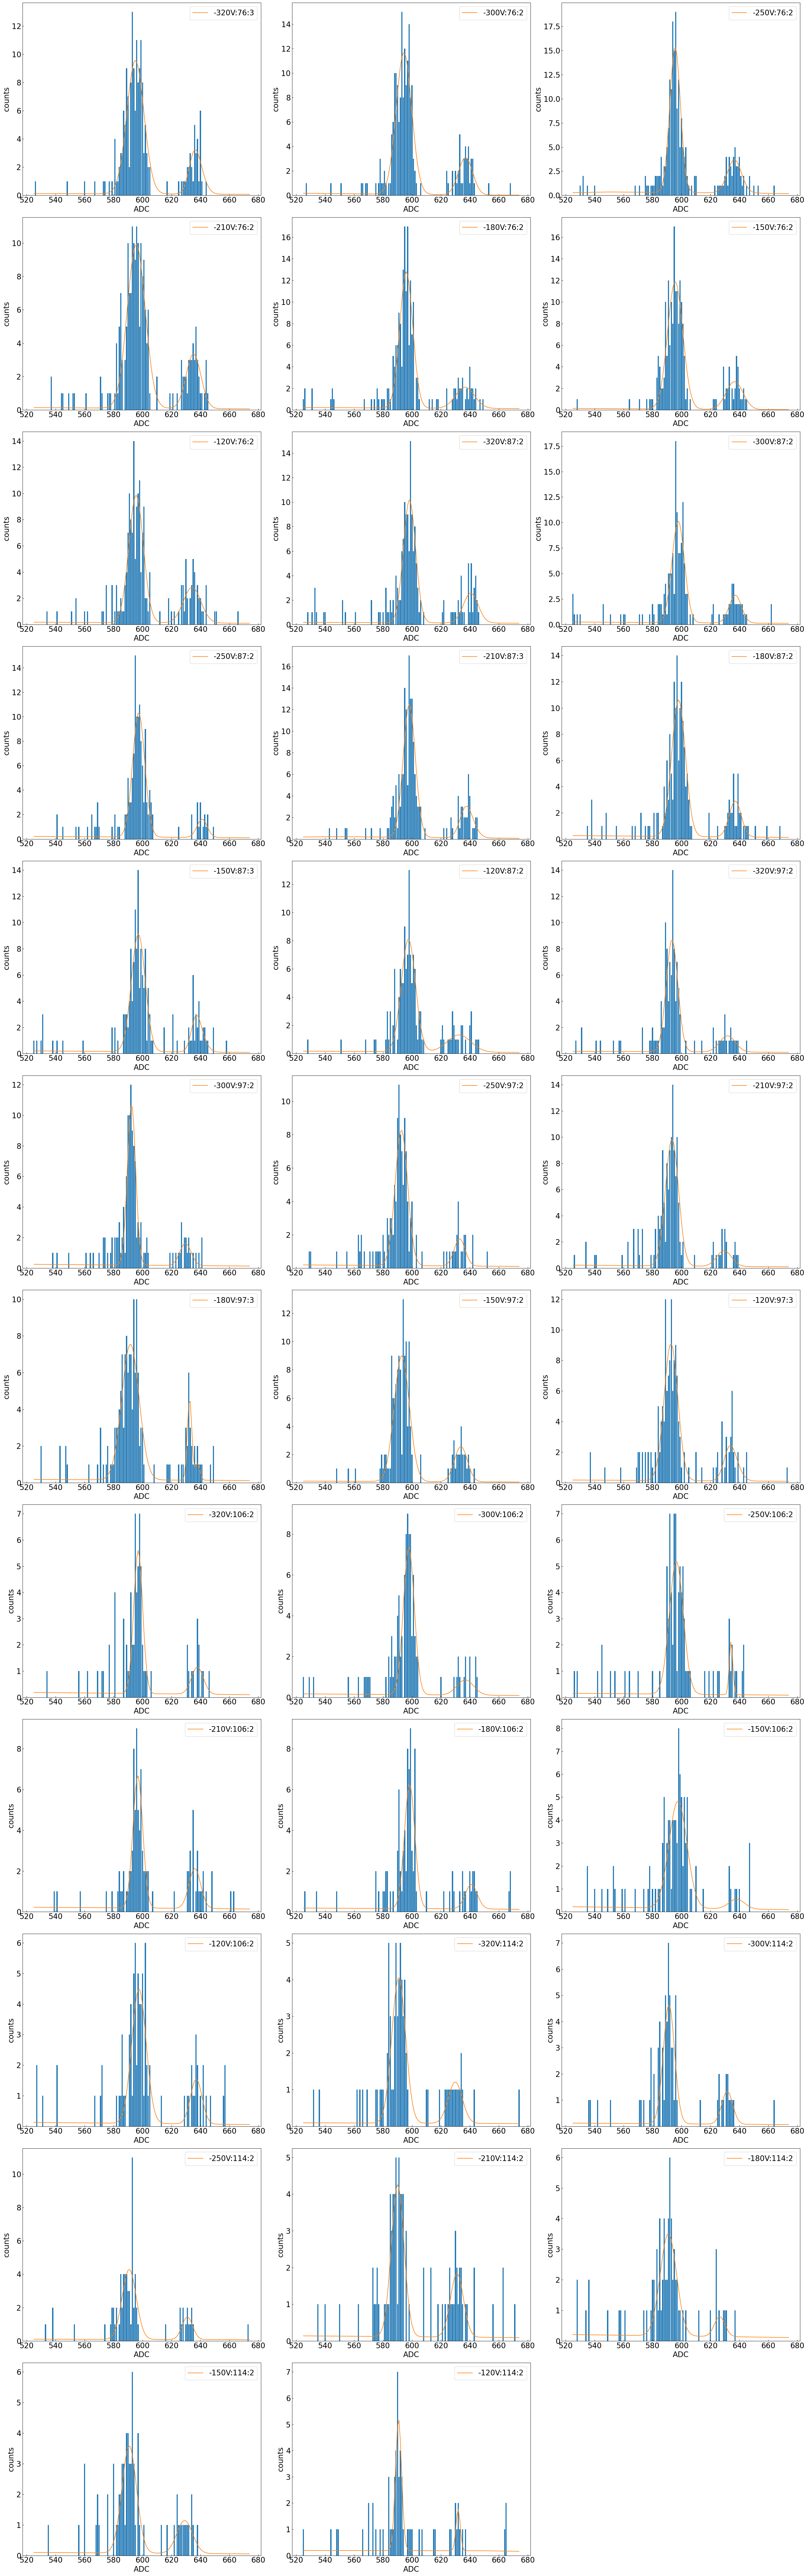

In [16]:
nrows,ncols=12,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(450,850)
conf['xray'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs2)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
#         ax.set_ylim(0,5)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==3:
            conf['capture'] = 'three'
            Sn = SnCalibration()
            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.legend(prop={'size':20})
            

        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==2:

            conf['capture'] = 'two'
            Sn = SnCalibration()

            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==1:
            conf['capture'] = 'one'
            Sn = SnCalibration()
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.legend(prop={'size':20})
py.tight_layout()

IndexError: single positional indexer is out-of-bounds

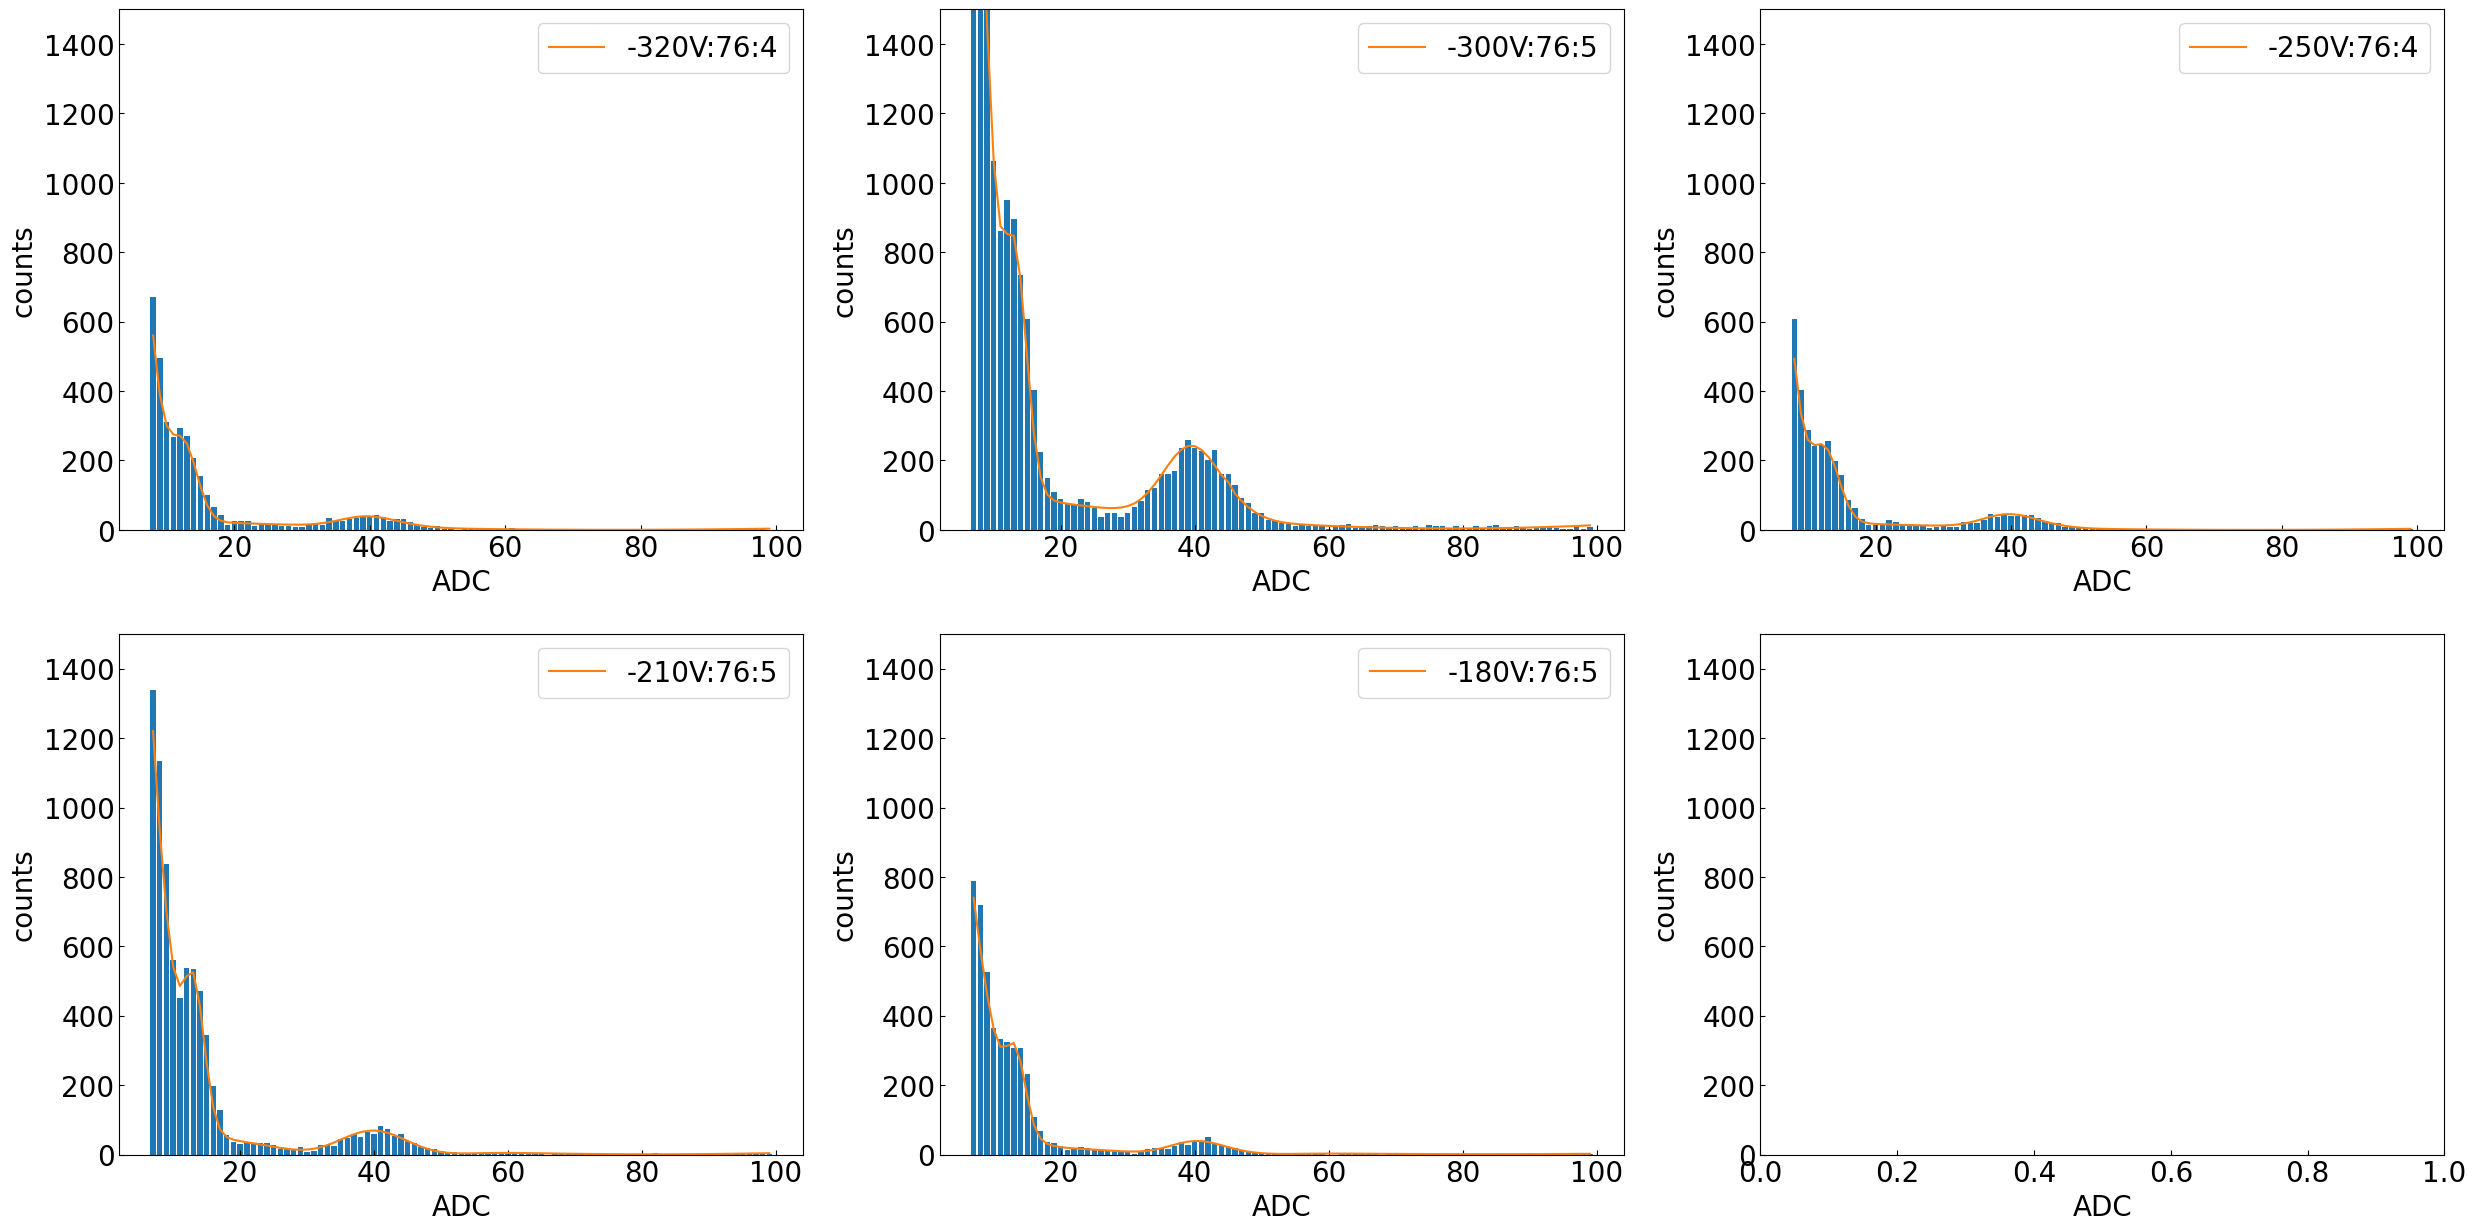

In [11]:
nrows,ncols=12,3
py.figure(figsize=(10*ncols,8*nrows))

conf['capture'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs2)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.set_ylim(0,1500)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        
        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==5:
            
            conf['xray'] = 'five'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==4:

            conf['xray'] = 'four'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)

            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==3:

            conf['xray'] = 'three'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)

            ax=py.subplot(nrows,ncols,cnt)

            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            
            ax.legend(prop={'size':20})

#         ax.set_ylim(0,500)
py.tight_layout()

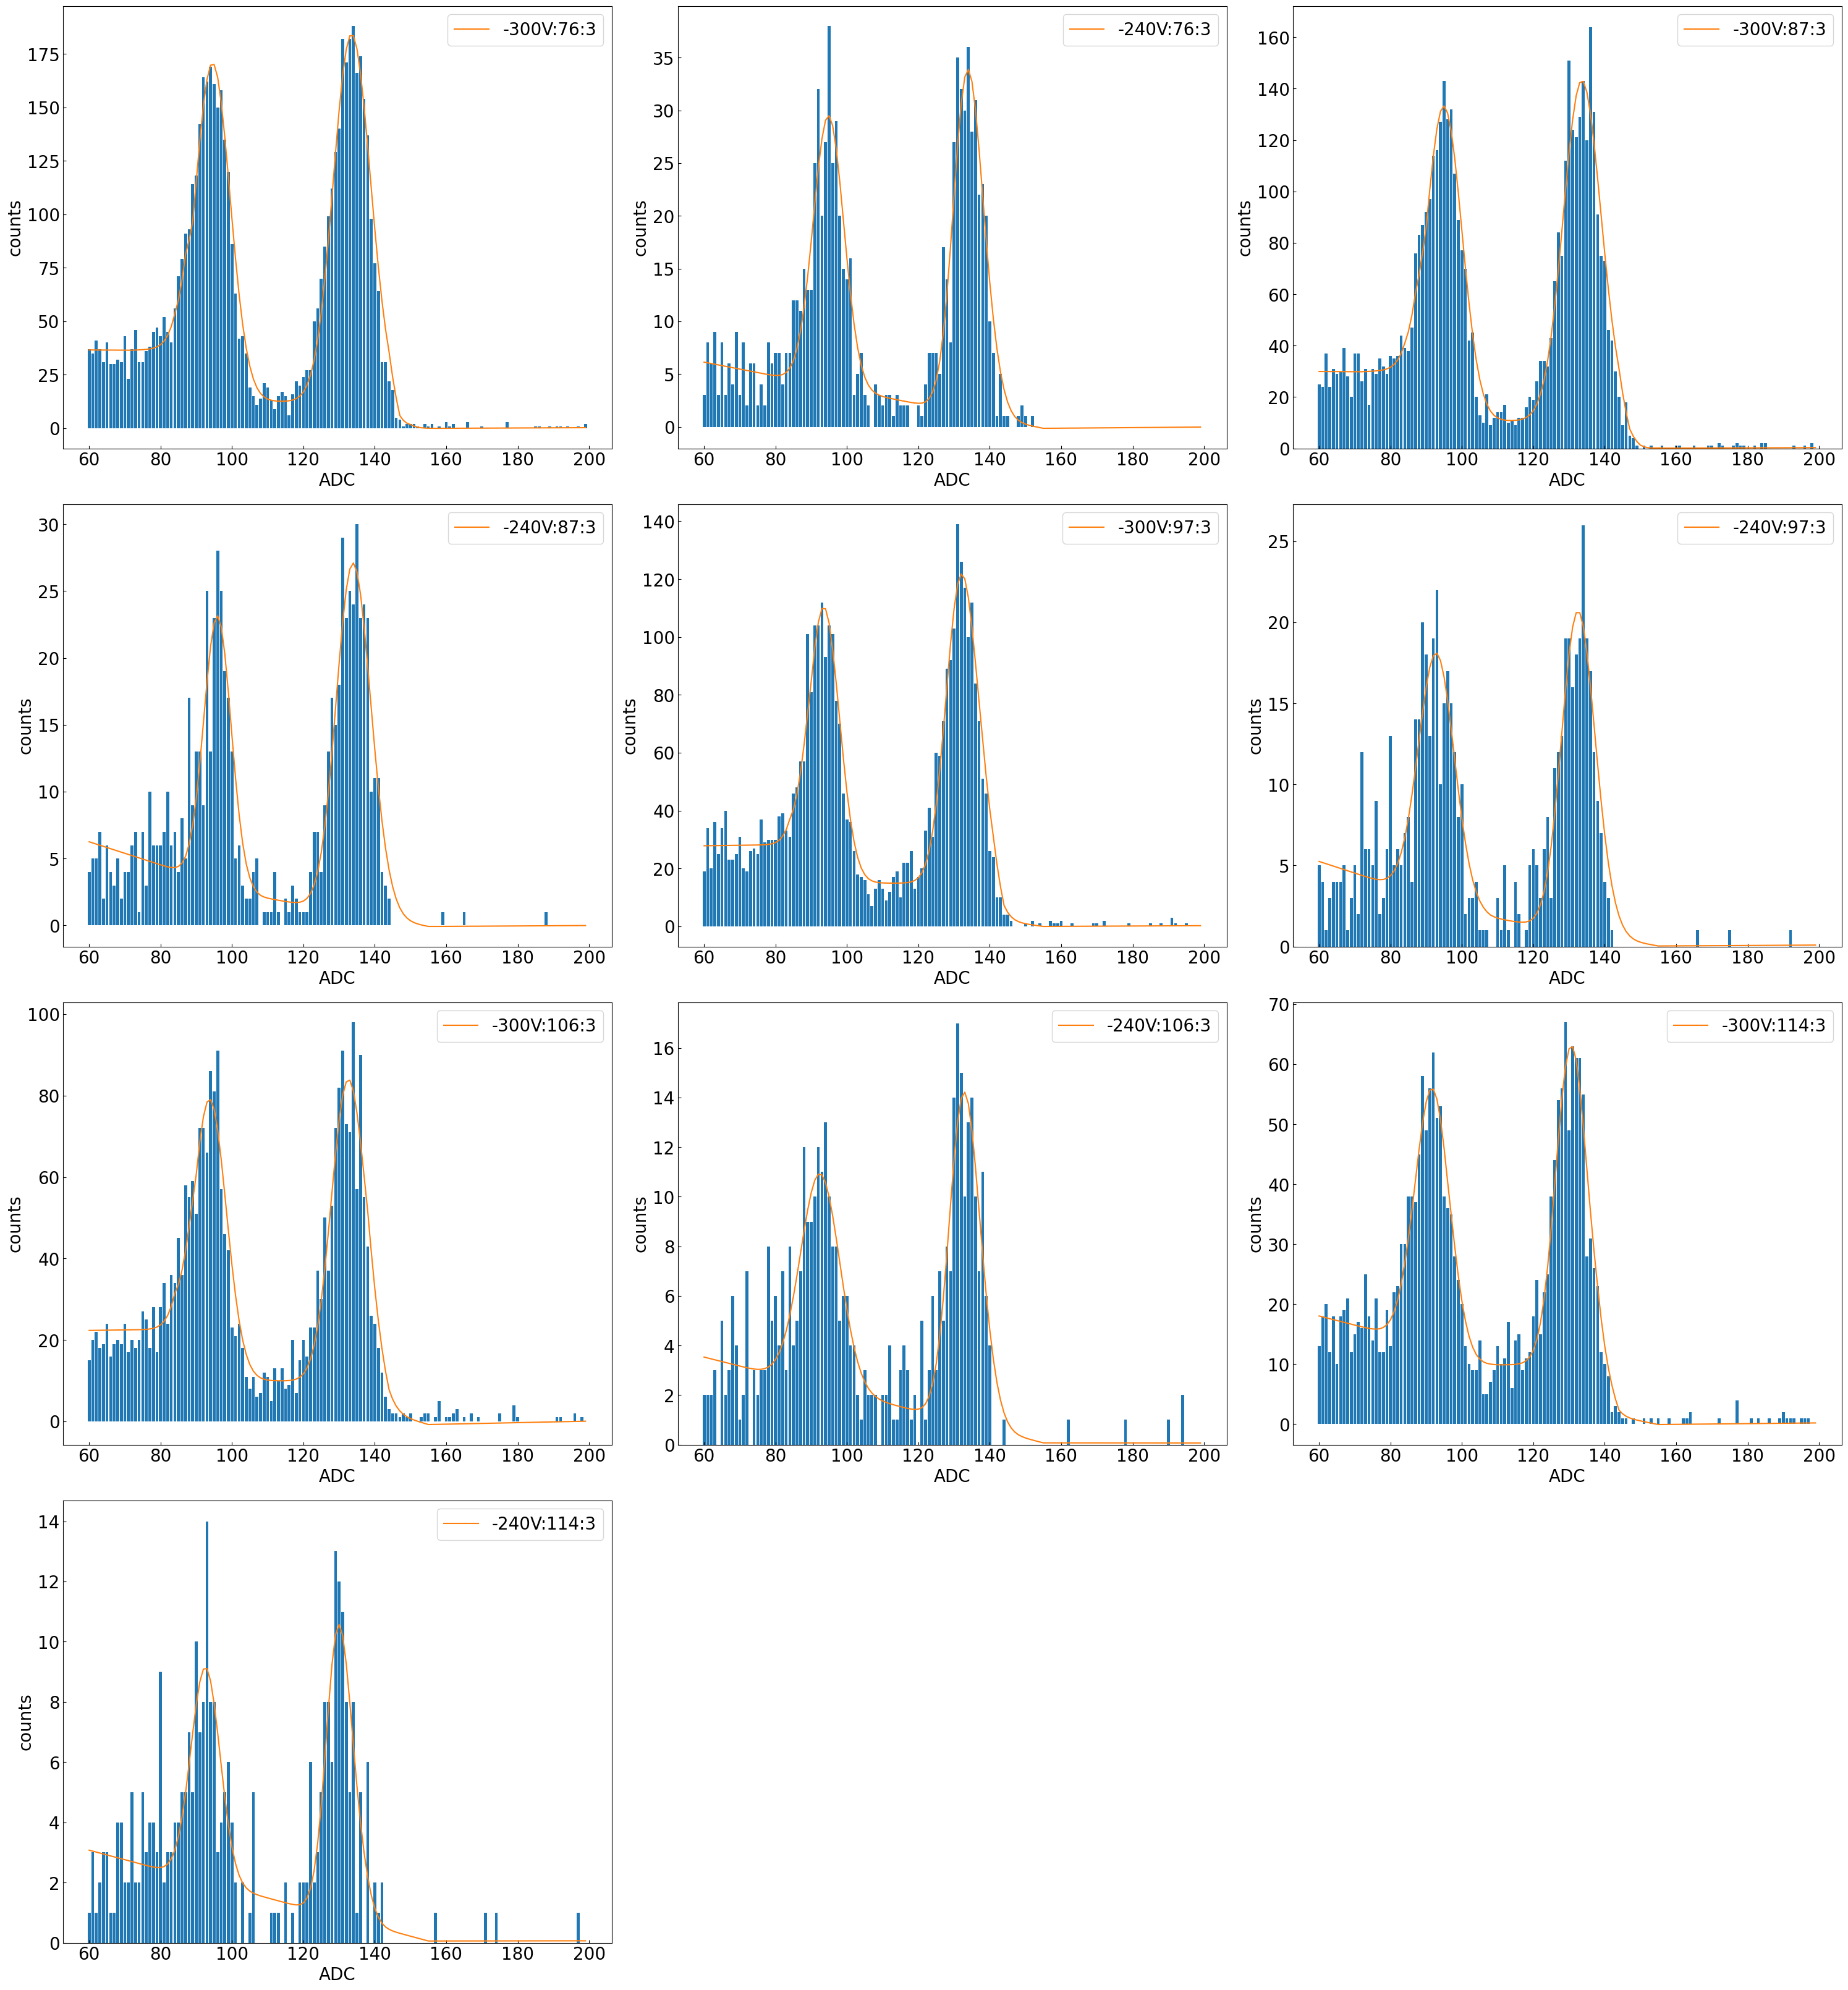

In [12]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(60,250)
conf['xray'] = 'OFF'
conf['new'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs_Cd)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
#         ax.set_ylim(0,45)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        
        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==3:
            conf['capture'] = 'three'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            ax.legend(prop={'size':20})
            

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==2:
            conf['capture'] = 'two'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==1:
            conf['capture'] = 'one'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            
            ax.legend(prop={'size':20})
py.tight_layout()

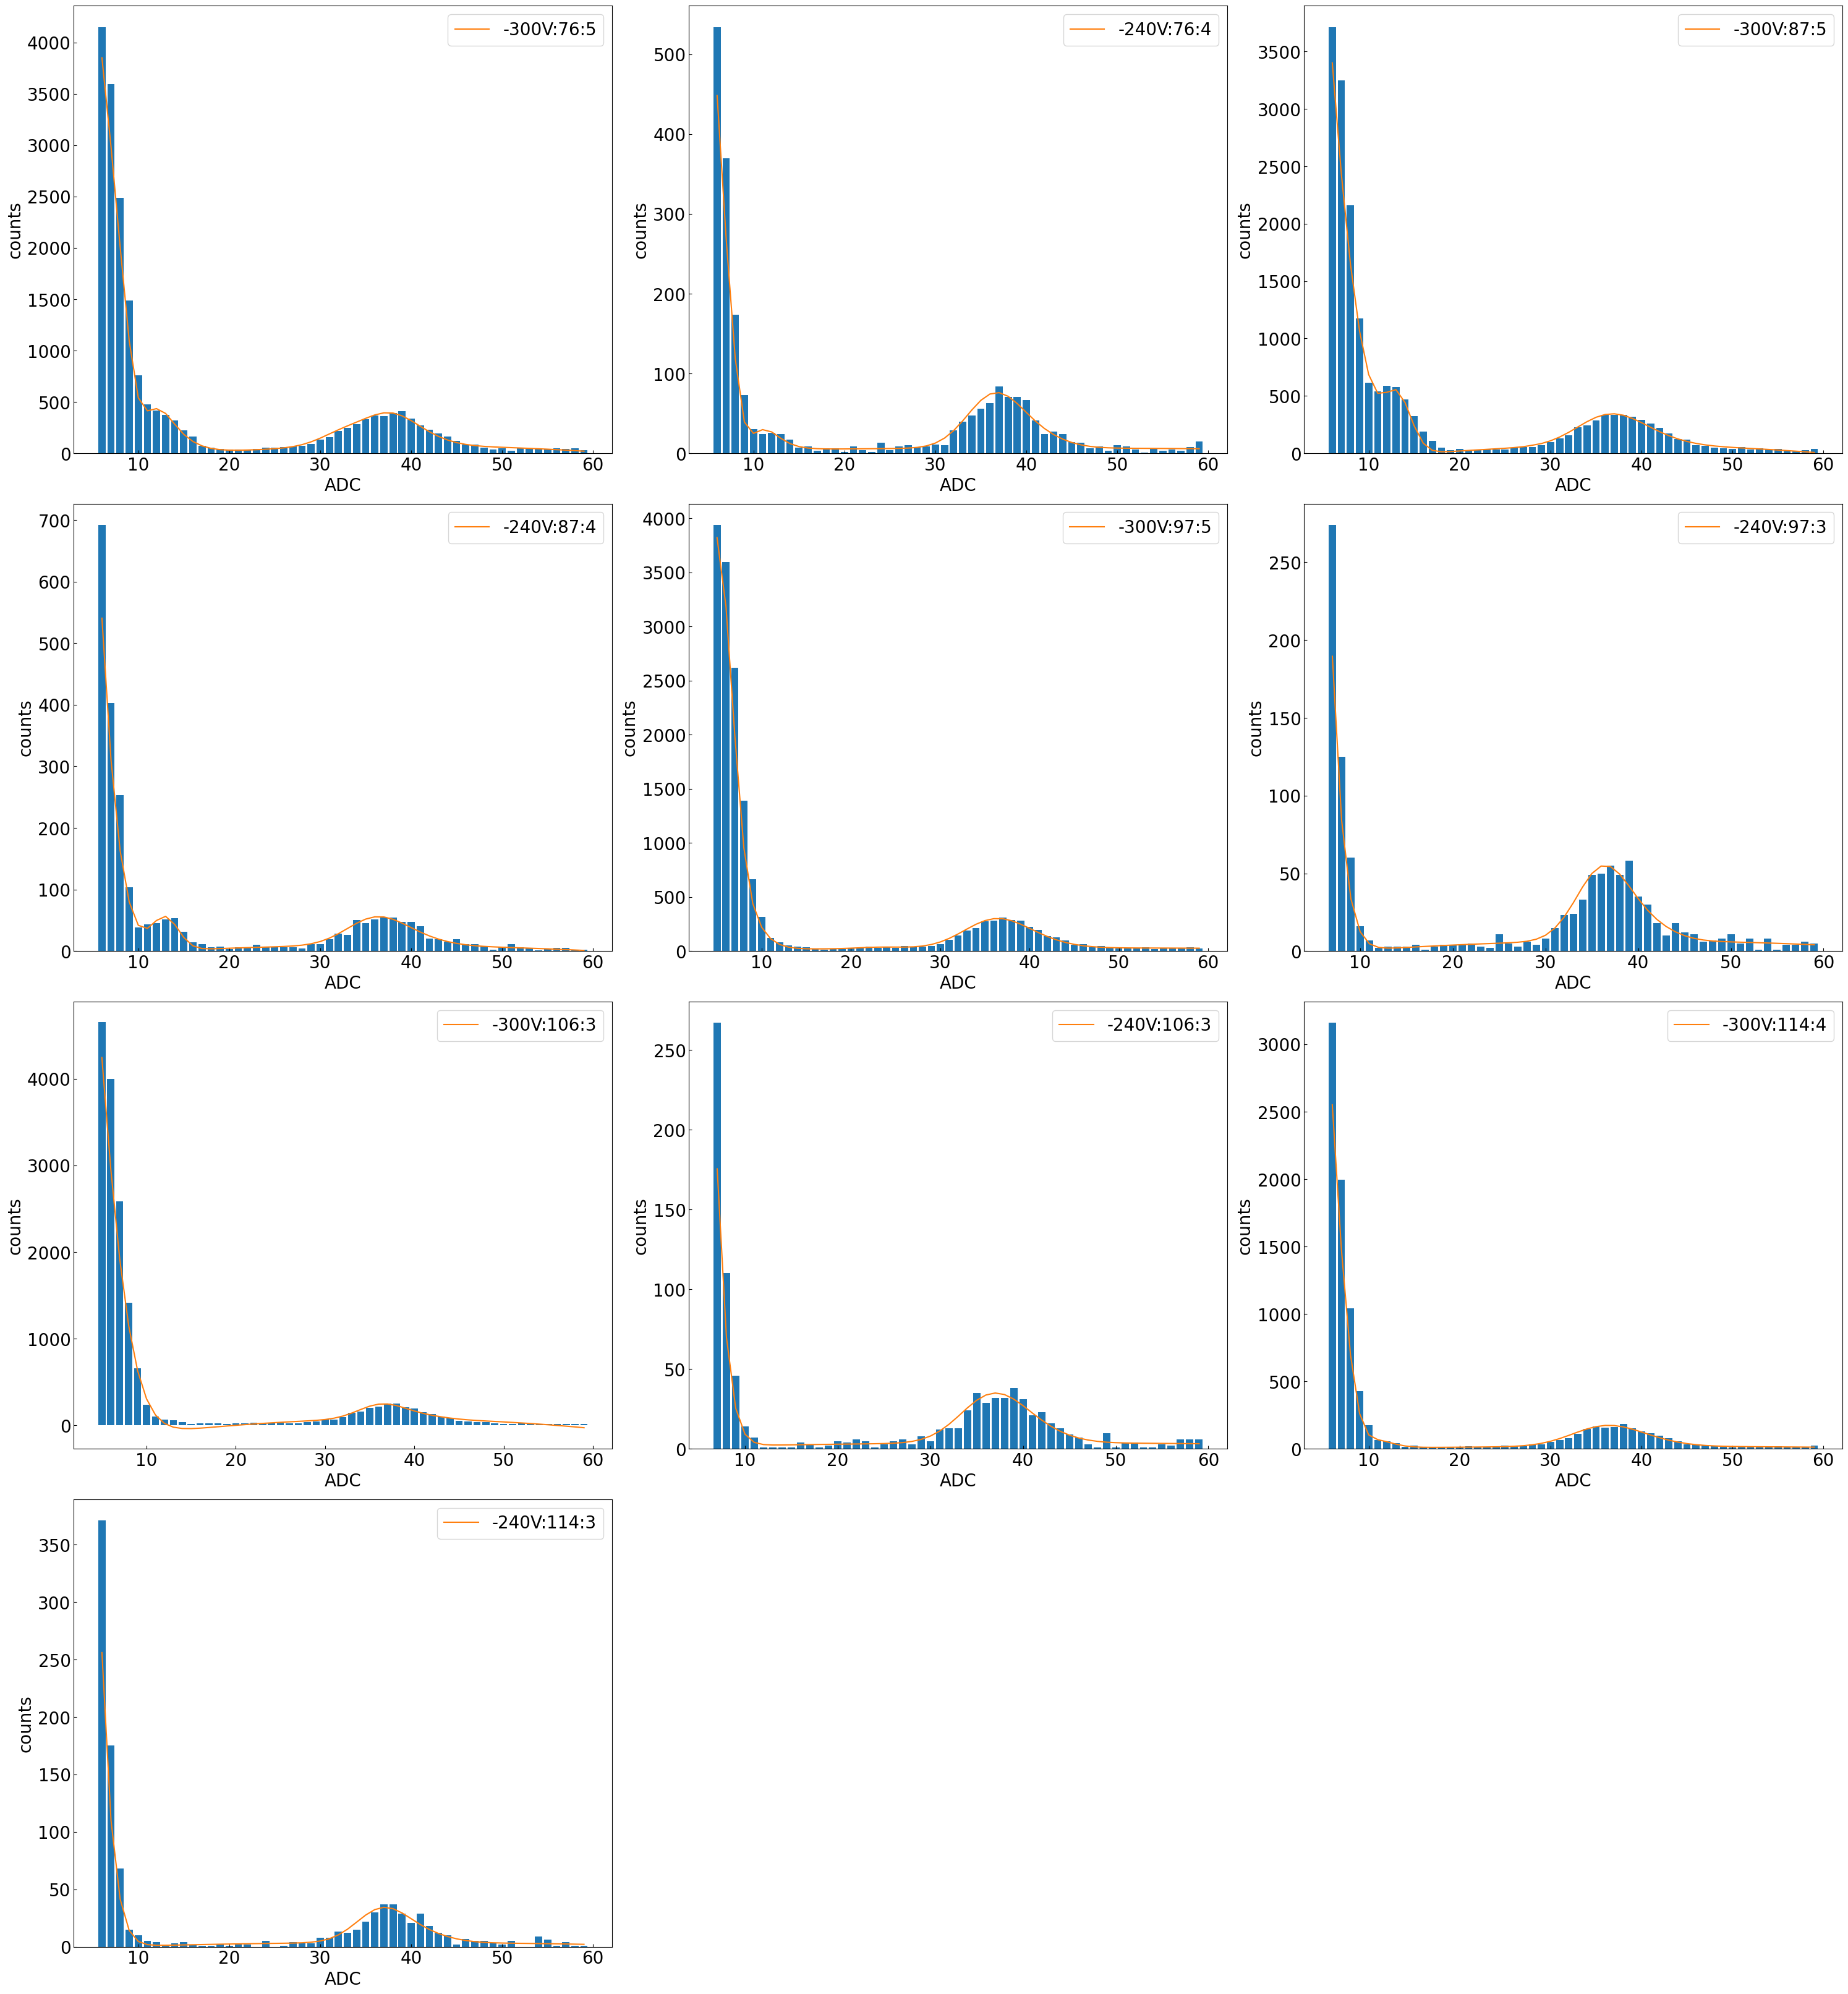

In [13]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(0,60)
conf['capture'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs_Cd)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
#         ax.set_ylim(0,1500)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==5:

            conf['xray'] = 'five'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==4:

            conf['xray'] = 'four'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==3:

            conf['xray'] = 'three'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)

            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias_Cd[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

#         ax.set_ylim(0,500)
py.tight_layout()